# BMI Neural Decoding — Signal Processing Analysis

Step-by-step exploration of the monkey reaching dataset.

**Sections:**
- **Section 0** — Data structure: what does the data actually look like?
- **Section 1** — Overall neuron activity: population-level feel
- **Section 2** — Directional tuning via z-score: which neuron responds to which direction?

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

dir_angles = np.array([30, 70, 110, 150, 190, 230, 310, 350]) # Direction angles (documented)

# Load data
mat_file = Path("/Users/po-yu/Desktop/Imperial/yr4/BIOE70011 Brain Machine Interfaces/BMI_Lab/monkeydata_training.mat")
data = sio.loadmat(str(mat_file))
print('data type: ', type(data))
# print(data)
print("Keys: ", list(data.keys()))

print('\n')

trial = data['trial']
print('trial type: ', type(trial))
print(f"trial.shape = {trial.shape}  ->   {trial.shape[0]} trials × {trial.shape[1]} directions")
print('trial dtype: ', trial.dtype)


data type:  <class 'dict'>
Keys:  ['__header__', '__version__', '__globals__', 'trial']


trial type:  <class 'numpy.ndarray'>
trial.shape = (100, 8)  ->   100 trials × 8 directions
trial dtype:  [('trialId', 'O'), ('spikes', 'O'), ('handPos', 'O')]


## Section 0 — Data Structure

Before any analysis: understand exactly what's in the data.

In [14]:
# Each element trial[i, j] has three fields
sample = trial[0, 0]
sp = sample['spikes']
hp = sample['handPos']
tid = int(sample['trialId'].flat[0])

print("Fields in trial[i, j]:")
print(f"  trialId  : scalar uint8, value = {tid}")
print(f"  spikes   : shape {sp.shape}  (neurons × time bins)")
print(f"             dtype={sp.dtype}, values={np.unique(sp)}  ← binary 0/1")
print(f"             spikes T = {sp.shape[1]}, handPos T = {hp.shape[1]}")
print(f"  handPos  : shape {hp.shape}  (X/Y/Z × time bins)")
print(f"             dtype={hp.dtype}")
print(f"             X range [{hp[0].min():.1f}, {hp[0].max():.1f}] mm")
print(f"             Y range [{hp[1].min():.1f}, {hp[1].max():.1f}] mm")
print(f"             Z range [{hp[2].min():.1f}, {hp[2].max():.1f}] mm")

# for i in range(num_trials):
#     print(i, int(trial[i, 0]['trialId'].flat[0]))


Fields in trial[i, j]:
  trialId  : scalar uint8, value = 111
  spikes   : shape (98, 672)  (neurons × time bins)
             dtype=uint8, values=[0 1]  ← binary 0/1
             spikes T = 672, handPos T = 672
  handPos  : shape (3, 672)  (X/Y/Z × time bins)
             dtype=float64
             X range [-15.6, 75.7] mm
             Y range [-8.1, 49.7] mm
             Z range [-18.2, -9.5] mm


In [15]:
num_trials, num_directions = trial.shape
num_neurons = trial['spikes'][0, 0].shape[0]

print(f"Data dimensions:")
print(f"  num_trials     = {num_trials}")
print(f"  num_directions = {num_directions}")
print(f"  num_neurons    = {num_neurons}")

# Trial duration across all 800 trials
durations = np.array([
    trial['spikes'][i, j].shape[1]
    for i in range(num_trials)
    for j in range(num_directions)
])

print(f"Trial durations across all {num_trials * num_directions} trials:")
print(f"  Min  = {durations.min()} ms")
print(f"  Max  = {durations.max()} ms")
print(f"  Mean = {durations.mean():.1f} ms")


Data dimensions:
  num_trials     = 100
  num_directions = 8
  num_neurons    = 98
Trial durations across all 800 trials:
  Min  = 571 ms
  Max  = 975 ms
  Mean = 643.6 ms


## Section 1 — Overall Neuron Activity

Before looking at directional tuning, get a population-level picture:
- How active is each neuron on average?
- When does the population collectively become active?

Range: [0.1, 66.5] Hz
Neurons with < 1 Hz (nearly silent): 7
Neurons with > 30 Hz (very active):  23


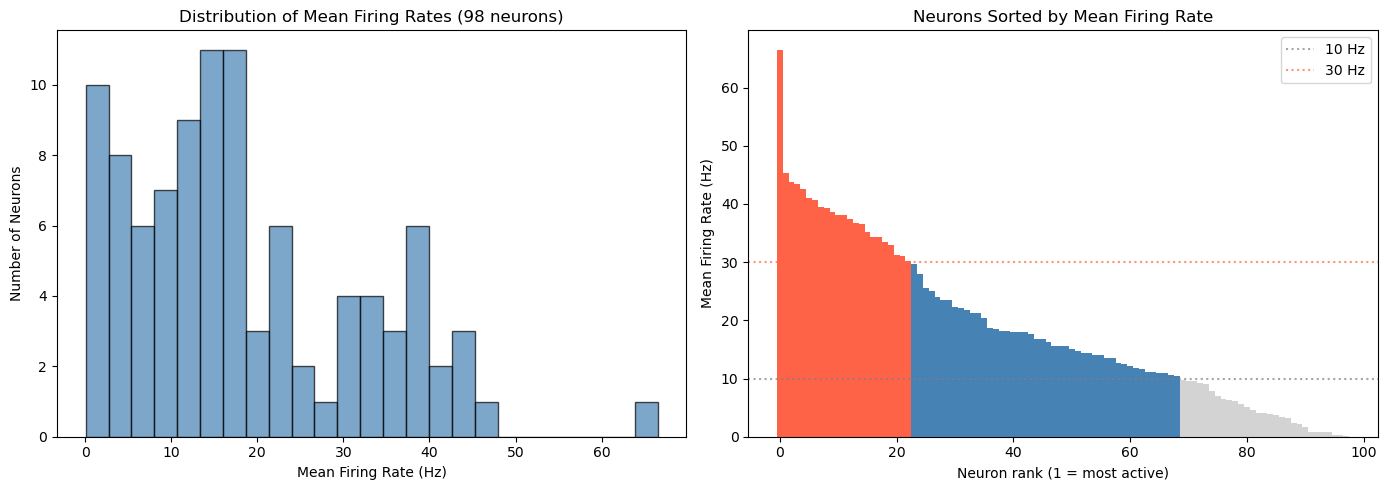

Neuron 95 has the highest mean firing rate: 66.5 Hz


In [17]:
# Mean firing rate per neuron (averaged over all 800 trials)
mean_fr = np.zeros(num_neurons)  # Hz

for i in range(num_trials):
    for j in range(num_directions):
        sp = trial['spikes'][i, j]
        T_s = sp.shape[1] / 1000  # duration in seconds
        mean_fr += sp.sum(axis=1) / T_s

mean_fr /= (num_trials * num_directions)

print(f"Range: [{mean_fr.min():.1f}, {mean_fr.max():.1f}] Hz")
print(f"Neurons with < 1 Hz (nearly silent): {(mean_fr < 1).sum()}")
print(f"Neurons with > 30 Hz (very active):  {(mean_fr > 30).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of firing rates
axes[0].hist(mean_fr, bins=25, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Mean Firing Rate (Hz)')
axes[0].set_ylabel('Number of Neurons')
axes[0].set_title('Distribution of Mean Firing Rates (98 neurons)')

# Bar chart sorted by firing rate
sorted_idx = np.argsort(mean_fr)[::-1]
colors = ['tomato' if r > 30 else 'steelblue' if r > 10 else 'lightgray'
          for r in mean_fr[sorted_idx]]
axes[1].bar(range(num_neurons), mean_fr[sorted_idx], color=colors, width=1.0, edgecolor='none')
axes[1].set_xlabel('Neuron rank (1 = most active)')
axes[1].set_ylabel('Mean Firing Rate (Hz)')
axes[1].set_title('Neurons Sorted by Mean Firing Rate')
axes[1].axhline(10, color='gray', linestyle=':', alpha=0.7, label='10 Hz')
axes[1].axhline(30, color='tomato', linestyle=':', alpha=0.7, label='30 Hz')
axes[1].legend()

plt.tight_layout()
plt.show()

max_neuron_idx = np.argmax(mean_fr)
print(f"Neuron {max_neuron_idx} has the highest mean firing rate: {mean_fr[max_neuron_idx]:.1f} Hz")

In [18]:
#sort mean firing rate from most active to inactive
sorted_idx = np.argsort(mean_fr)[::-1]
for rank, i in enumerate(sorted_idx):
    print(f"Rank {rank+1}: Neuron {i} — {mean_fr[i]:.1f} Hz")

Rank 1: Neuron 95 — 66.5 Hz
Rank 2: Neuron 97 — 45.3 Hz
Rank 3: Neuron 33 — 43.7 Hz
Rank 4: Neuron 35 — 43.5 Hz
Rank 5: Neuron 74 — 42.6 Hz
Rank 6: Neuron 86 — 40.9 Hz
Rank 7: Neuron 3 — 40.6 Hz
Rank 8: Neuron 40 — 39.5 Hz
Rank 9: Neuron 91 — 39.4 Hz
Rank 10: Neuron 84 — 38.6 Hz
Rank 11: Neuron 54 — 38.1 Hz
Rank 12: Neuron 66 — 38.0 Hz
Rank 13: Neuron 60 — 37.3 Hz
Rank 14: Neuron 21 — 36.7 Hz
Rank 15: Neuron 55 — 36.6 Hz
Rank 16: Neuron 80 — 35.2 Hz
Rank 17: Neuron 67 — 34.4 Hz
Rank 18: Neuron 85 — 34.3 Hz
Rank 19: Neuron 87 — 33.5 Hz
Rank 20: Neuron 6 — 32.9 Hz
Rank 21: Neuron 47 — 31.2 Hz
Rank 22: Neuron 76 — 31.1 Hz
Rank 23: Neuron 65 — 30.1 Hz
Rank 24: Neuron 26 — 29.7 Hz
Rank 25: Neuron 28 — 28.0 Hz
Rank 26: Neuron 39 — 25.6 Hz
Rank 27: Neuron 79 — 25.0 Hz
Rank 28: Neuron 13 — 24.0 Hz
Rank 29: Neuron 8 — 23.5 Hz
Rank 30: Neuron 88 — 23.4 Hz
Rank 31: Neuron 44 — 22.2 Hz
Rank 32: Neuron 71 — 22.1 Hz
Rank 33: Neuron 17 — 21.7 Hz
Rank 34: Neuron 46 — 21.3 Hz
Rank 35: Neuron 64 — 21.3 

Baseline window: [0, 130] ms
Range: [0.0, 58.5] Hz
Neurons with < 1 Hz (nearly silent): 9
Neurons with > 30 Hz (very active):  4


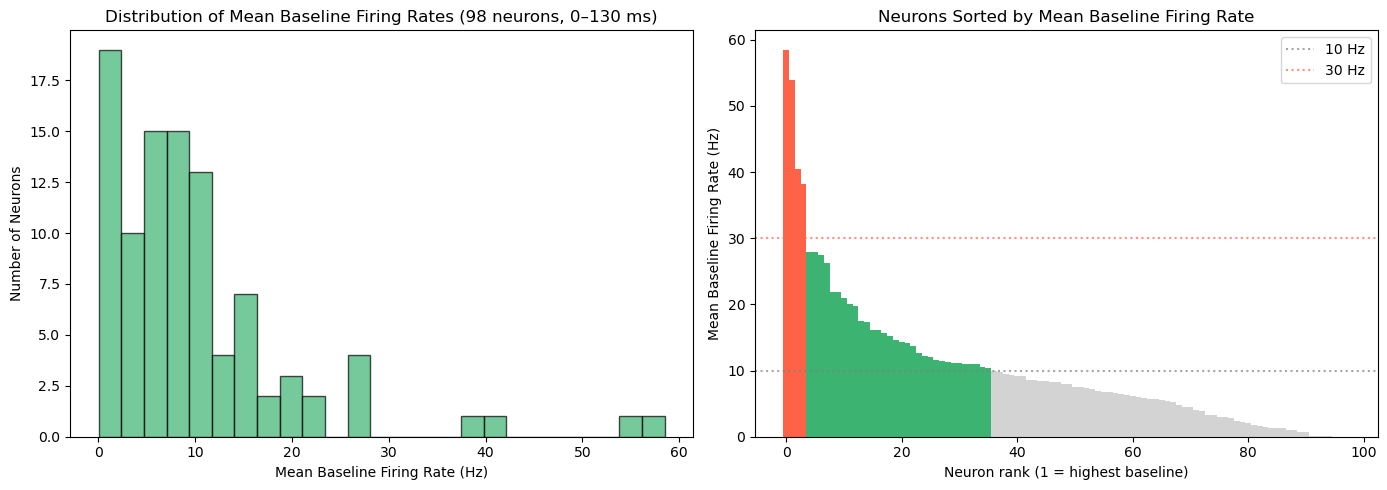

Neuron 95 has the highest mean baseline firing rate: 58.5 Hz


In [32]:
# Mean BASELINE firing rate per neuron (averaged over all 800 trials, pre-movement only)
# Baseline window: [0, 300 ms] — before movement onset

BL_END = 130  # ms

baseline_fr = np.zeros(num_neurons)  # Hz

for i in range(num_trials):
    for j in range(num_directions):
        sp = trial['spikes'][i, j]
        bl_spikes = sp[:, :BL_END]          # first 130 ms only
        baseline_fr += bl_spikes.sum(axis=1) / (BL_END / 1000)  # convert ms → s

baseline_fr /= (num_trials * num_directions)

print(f"Baseline window: [0, {BL_END}] ms")
print(f"Range: [{baseline_fr.min():.1f}, {baseline_fr.max():.1f}] Hz")
print(f"Neurons with < 1 Hz (nearly silent): {(baseline_fr < 1).sum()}")
print(f"Neurons with > 30 Hz (very active):  {(baseline_fr > 30).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of baseline firing rates
axes[0].hist(baseline_fr, bins=25, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[0].set_xlabel('Mean Baseline Firing Rate (Hz)')
axes[0].set_ylabel('Number of Neurons')
axes[0].set_title(f'Distribution of Mean Baseline Firing Rates (98 neurons, 0–{BL_END} ms)')

# Bar chart sorted by baseline firing rate
sorted_idx_bl = np.argsort(baseline_fr)[::-1]
colors_bl = ['tomato' if r > 30 else 'mediumseagreen' if r > 10 else 'lightgray'
             for r in baseline_fr[sorted_idx_bl]]
axes[1].bar(range(num_neurons), baseline_fr[sorted_idx_bl], color=colors_bl, width=1.0, edgecolor='none')
axes[1].set_xlabel('Neuron rank (1 = highest baseline)')
axes[1].set_ylabel('Mean Baseline Firing Rate (Hz)')
axes[1].set_title('Neurons Sorted by Mean Baseline Firing Rate')
axes[1].axhline(10, color='gray', linestyle=':', alpha=0.7, label='10 Hz')
axes[1].axhline(30, color='tomato', linestyle=':', alpha=0.7, label='30 Hz')
axes[1].legend()

plt.tight_layout()
plt.show()

max_bl_idx = np.argmax(baseline_fr)
print(f"Neuron {max_bl_idx} has the highest mean baseline firing rate: {baseline_fr[max_bl_idx]:.1f} Hz")


In [33]:
#sort baseline firing rate from most active to inactive
baseline_idx = np.argsort(baseline_fr)[::-1]
for rank, i in enumerate(baseline_idx):
    print(f"Rank {rank+1}: Neuron {i} — {baseline_fr[i]:.1f} Hz")

Rank 1: Neuron 95 — 58.5 Hz
Rank 2: Neuron 86 — 54.0 Hz
Rank 3: Neuron 35 — 40.4 Hz
Rank 4: Neuron 84 — 38.2 Hz
Rank 5: Neuron 3 — 27.9 Hz
Rank 6: Neuron 40 — 27.9 Hz
Rank 7: Neuron 21 — 27.4 Hz
Rank 8: Neuron 6 — 26.2 Hz
Rank 9: Neuron 92 — 21.9 Hz
Rank 10: Neuron 67 — 21.9 Hz
Rank 11: Neuron 44 — 20.9 Hz
Rank 12: Neuron 76 — 20.1 Hz
Rank 13: Neuron 65 — 19.7 Hz
Rank 14: Neuron 55 — 17.4 Hz
Rank 15: Neuron 39 — 17.4 Hz
Rank 16: Neuron 8 — 16.2 Hz
Rank 17: Neuron 96 — 16.1 Hz
Rank 18: Neuron 16 — 15.7 Hz
Rank 19: Neuron 90 — 15.2 Hz
Rank 20: Neuron 15 — 14.6 Hz
Rank 21: Neuron 56 — 14.3 Hz
Rank 22: Neuron 87 — 14.1 Hz
Rank 23: Neuron 36 — 13.8 Hz
Rank 24: Neuron 71 — 12.6 Hz
Rank 25: Neuron 60 — 12.2 Hz
Rank 26: Neuron 97 — 12.1 Hz
Rank 27: Neuron 58 — 11.6 Hz
Rank 28: Neuron 46 — 11.4 Hz
Rank 29: Neuron 89 — 11.3 Hz
Rank 30: Neuron 2 — 11.1 Hz
Rank 31: Neuron 20 — 11.1 Hz
Rank 32: Neuron 13 — 11.0 Hz
Rank 33: Neuron 0 — 11.0 Hz
Rank 34: Neuron 83 — 11.0 Hz
Rank 35: Neuron 66 — 10.5 Hz

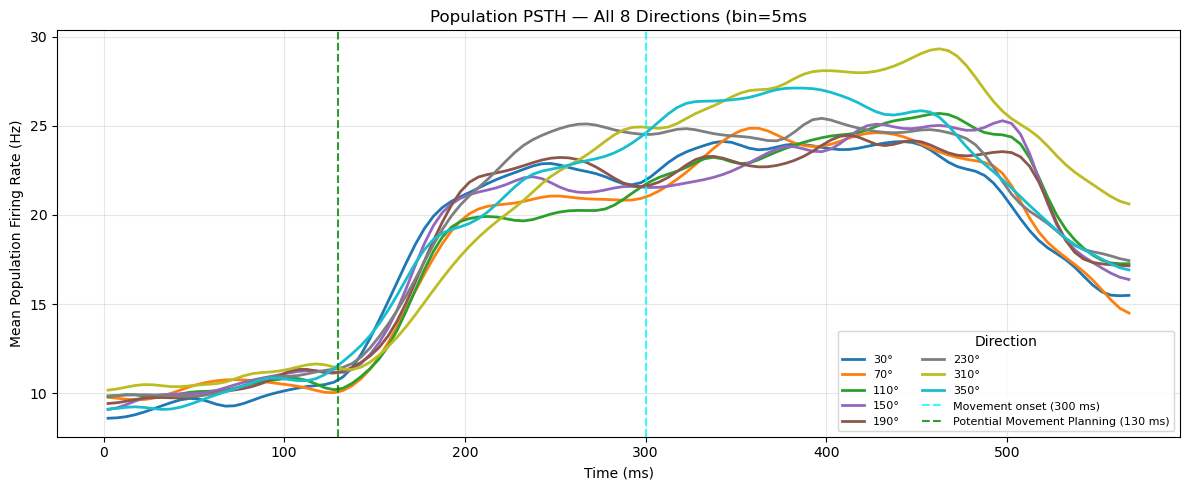

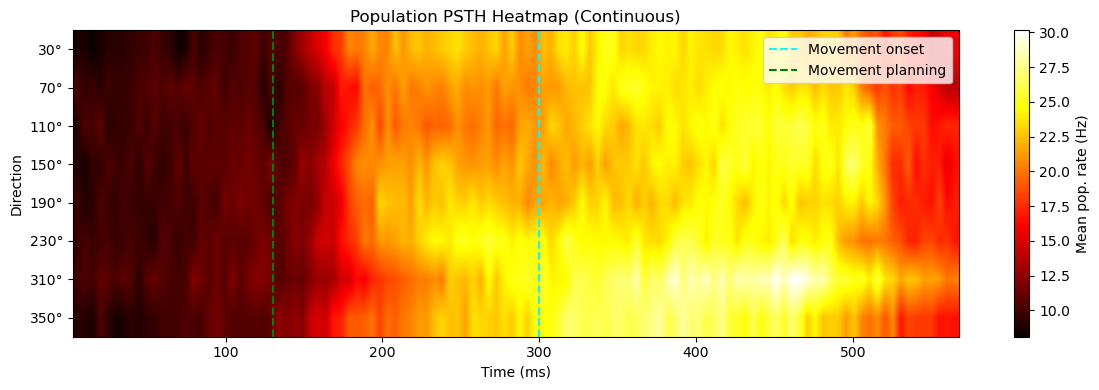

In [67]:
# Population PSTH: mean spike rate across all neurons over time
# Separate line per direction to see when/how the population responds

bin_size = 5  # ms
sigma_ms = 10  # Gaussian smoothing (ms)
sigma_bins = sigma_ms / bin_size

# Find a common time length (use min across all trials)
min_T = min(
    trial['spikes'][i, j].shape[1]
    for i in range(num_trials)
    for j in range(num_directions)
)
n_bins = min_T // bin_size
t_centers = np.arange(n_bins) * bin_size + bin_size / 2  # ms

pop_psth = np.zeros((num_directions, n_bins))  # mean population rate per direction

for j in range(num_directions):
    for i in range(num_trials):
        sp = trial['spikes'][i, j][:, :n_bins * bin_size]  # truncate to min_T
        # Bin into 5ms windows, sum across neurons, convert to Hz
        binned = sp.reshape(num_neurons, n_bins, bin_size).sum(axis=2)  # (98, n_bins)
        pop_rate = binned.mean(axis=0) / (bin_size / 1000)  # Hz (population mean)
        pop_psth[j] += pop_rate
    pop_psth[j] /= num_trials  # average over trials

# Smooth
pop_psth_smooth = gaussian_filter1d(pop_psth, sigma=sigma_bins, axis=1)

colors_dir = cm.tab10(np.linspace(0, 1, num_directions))

fig, ax = plt.subplots(figsize=(12, 5))
for j in range(num_directions):
    ax.plot(t_centers, pop_psth_smooth[j], color=colors_dir[j],
            linewidth=2, label=f'{dir_angles[j]}°') # change to pop_psth_smooth[j] for gaussian smoothing

ax.axvline(300, color='cyan', linestyle='--', linewidth=1.5, alpha=0.8, label='Movement onset (300 ms)')
ax.axvline(130, color='green', linestyle='--', linewidth=1.5, alpha=0.8, label='Potential Movement Planning (130 ms)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Mean Population Firing Rate (Hz)')
ax.set_title(f'Population PSTH — All 8 Directions (bin={bin_size}ms')
ax.legend(title='Direction', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also show as a heatmap across directions (continuous color + smooth interpolation)
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(
    pop_psth,
    aspect='auto',
    cmap='hot',
    interpolation='bilinear',
    extent=[t_centers[0], t_centers[-1], num_directions - 0.5, -0.5]
)
ax.axvline(300, color='cyan', linestyle='--', linewidth=1.5, label='Movement onset')
ax.axvline(130, color='green', linestyle='--', linewidth=1.5, label='Movement planning')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Direction')
ax.set_yticks(range(num_directions))
ax.set_yticklabels([f'{a}°' for a in dir_angles])
ax.set_title('Population PSTH Heatmap (Continuous)')
ax.legend()
plt.colorbar(im, ax=ax, label='Mean pop. rate (Hz)')
plt.tight_layout()
plt.show()

In [31]:
import io
import ipywidgets as widgets
from IPython.display import display

# ── widgets ───────────────────────────────────────────────────────────────────
w_neuron = widgets.IntSlider(value=86, min=0, max=97, step=1,
                             description='Neuron', style={'description_width': '60px'})
w_start  = widgets.IntSlider(value=0,  min=0, max=97, step=1,
                             description='1st trial', style={'description_width': '60px'})
w_dir    = widgets.Dropdown(
    options=[(f'{a}°', i) for i, a in enumerate(dir_angles)],
    value=5, description='Direction', style={'description_width': '60px'}
)
w_n      = widgets.RadioButtons(options=[1, 3, 5], value=5,
                                description='# trials', style={'description_width': '60px'})

img_widget = widgets.Image(format='png', width='100%')

def _clamp_start(*_):
    w_start.max = 100 - w_n.value
    if w_start.value > w_start.max:
        w_start.value = w_start.max
w_n.observe(_clamp_start, names='value')

# ── plot function ─────────────────────────────────────────────────────────────
def plot_raster(*_):
    neuron_id   = w_neuron.value
    start_trial = w_start.value
    dir_idx     = w_dir.value
    n_trials    = w_n.value

    trial_ids = list(range(start_trial, min(start_trial + n_trials, 100)))
    max_T = max(len(trial['spikes'][t, dir_idx][neuron_id, :]) for t in trial_ids)

    fig, axes = plt.subplots(
        len(trial_ids), 1,
        figsize=(10, len(trial_ids) * 0.85 + 0.6),
        sharex=True
    )
    if len(trial_ids) == 1:
        axes = [axes]

    for row, t_id in enumerate(trial_ids):
        sp = trial['spikes'][t_id, dir_idx][neuron_id, :]
        spike_times = np.where(sp)[0]
        n_spk = len(spike_times)

        axes[row].vlines(spike_times, ymin=0.55, ymax=1.0, color='black', linewidth=1)
        axes[row].axvline(300, color='steelblue', linestyle='--', linewidth=1.2, alpha=0.8)
        axes[row].axvline(130, color='green',     linestyle='--', linewidth=1.2, alpha=0.8)
        axes[row].set_xlim(0, max_T)
        axes[row].set_ylim(0.5, 1.5)
        axes[row].set_yticks([])
        axes[row].set_ylabel(f'T{t_id}\n({n_spk} spk)',
                             fontsize=7.5, rotation=0, labelpad=38, va='center')

    axes[0].text(302, 1.52, 'Onset (300 ms)',   color='steelblue', fontsize=7.5, va='bottom', clip_on=False)
    axes[0].text(132, 1.52, 'Planning (130 ms)', color='green',     fontsize=7.5, va='bottom', clip_on=False)

    axes[-1].set_xlabel('Time (ms)')
    fig.suptitle(
        f'Neuron {neuron_id}  —  {dir_angles[dir_idx]}°  —  '
        f'{len(trial_ids)} trial{"s" if len(trial_ids) > 1 else ""}',
        fontsize=11, y=1.01
    )
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    img_widget.value = buf.getvalue()

# ── wire up & render ──────────────────────────────────────────────────────────
for w in [w_neuron, w_start, w_dir, w_n]:
    w.observe(plot_raster, names='value')

plot_raster()

display(widgets.VBox([
    widgets.HBox([w_neuron, w_dir]),
    widgets.HBox([w_start,  w_n]),
    img_widget,
]))

## Section 1b — Per-Direction Neuron Inspector: 98-Neuron PSTH Heatmap

**Goal:** For one chosen direction, see *all 98 neurons simultaneously* — when they fire relative to movement onset, and how far they deviate from their individual baseline.

**What to look for:**
- **Direction-tuned neurons**: z-score peaks strongly for *this* direction — good regression features.
- **Planning neurons**: z-score rises *before* 300 ms — carry pre-movement intention signal.
- **Broadly active neurons**: fire for all directions (speed/effort signal, weak direction regression value).
- **Suppressed neurons** (blue traces): directional inhibition — still informative.

**Using this for regression:**  
`BIN_SIZE` and `SIGMA_MS` below set the temporal resolution of features. The summary table at the bottom gives each neuron's preferred direction, peak z-score, peak time, and modulation depth — directly usable as feature-selection criteria.

In [58]:

# ═══════════════════════════════════════════════════════════════════════════
# PARAMETERS  ← change these to explore different directions / sorting modes
# ═══════════════════════════════════════════════════════════════════════════
DIR_IDX    = 0       # direction to inspect (0–7) → dir_angles[DIR_IDX]
BIN_SIZE   = 10      # ms — resampling bin width
SIGMA_MS   = 5       # ms — Gaussian smoothing kernel width
SORT_BY    = 'pref'  # 'pref' | 'peak' | 'onset'
MOVE_ONSET = 300     # ms — movement onset

direction_label = dir_angles[DIR_IDX]
sigma_bins      = SIGMA_MS / BIN_SIZE
print(f"Direction: {direction_label}°  |  sort={SORT_BY}  |  bin={BIN_SIZE}ms  σ={SIGMA_MS}ms")


Direction: 30°  |  sort=pref  |  bin=10ms  σ=5ms


In [59]:

# ── Baseline: reuse bl_mean from Section 1, compute bl_std ───────────────────
# baseline_fr (cell 096944a0) = mean FR over [0, 130ms], averaged across all 800 trials
# → mathematically identical to what we need for bl_mean; no recomputation needed.

BL_END  = 130                    # ms — matches Section 1 window
bl_mean = baseline_fr            # reuse from Section 1 (shape: num_neurons,)

# Compute per-neuron SD of baseline FR across all 800 trials
_bl = np.zeros((num_neurons, num_trials * num_directions))
k   = 0
for i in range(num_trials):
    for j in range(num_directions):
        sp = trial['spikes'][i, j]
        _bl[:, k] = sp[:, :BL_END].sum(axis=1) / (BL_END / 1000)
        k += 1
bl_std = _bl.std(axis=1, ddof=1)

print(f"Baseline [0, {BL_END}ms]")
print(f"  bl_mean : [{bl_mean.min():.1f}, {bl_mean.max():.1f}] Hz")
print(f"  bl_std  : [{bl_std.min():.2f}, {bl_std.max():.2f}] Hz")


Baseline [0, 130ms]
  bl_mean : [0.0, 58.5] Hz
  bl_std  : [0.47, 23.03] Hz


In [60]:

# ── Trial-averaged z-score traces (for DIR_IDX direction) ────────────────────

# Build common time grid for this direction
min_T_dir = min(trial['spikes'][i, DIR_IDX].shape[1] for i in range(num_trials))
n_bins    = min_T_dir // BIN_SIZE
t_ms      = np.arange(n_bins) * BIN_SIZE + BIN_SIZE / 2     # bin centres (ms)

# Trial-averaged firing rate → smooth → z-score
avg_rate = np.zeros((num_neurons, n_bins))
for i in range(num_trials):
    sp = trial['spikes'][i, DIR_IDX][:, :n_bins * BIN_SIZE]
    avg_rate += sp.reshape(num_neurons, n_bins, BIN_SIZE).sum(axis=2) / (BIN_SIZE / 1000)
avg_rate  /= num_trials
avg_smooth = gaussian_filter1d(avg_rate, sigma=sigma_bins, axis=1)

z_trace   = np.where(bl_std[:, None] > 0,
                     (avg_smooth - bl_mean[:, None]) / bl_std[:, None], 0.0)
peak_z    = z_trace.max(axis=1)
peak_time = t_ms[np.argmax(z_trace, axis=1)]

print(f"Time grid : {n_bins} bins × {BIN_SIZE}ms  →  [{t_ms[0]:.0f}, {t_ms[-1]:.0f}] ms")
print(f"Peak z    : [{peak_z.min():.2f}, {peak_z.max():.2f}] SD")
print(f"Pre-onset : {(peak_time < MOVE_ONSET).sum()} neurons peak before {MOVE_ONSET}ms")


Time grid : 59 bins × 10ms  →  [5, 585] ms
Peak z    : [-0.70, 103.58] SD
Pre-onset : 35 neurons peak before 300ms


In [61]:

# ── Preferred direction + planning/movement + Population scatter ──────────────

# ── 1. z_all: per-neuron z-score for each direction (post-movement average) ──
z_all = np.zeros((num_neurons, num_directions))
for j in range(num_directions):
    for i in range(num_trials):
        sp   = trial['spikes'][i, j]
        resp = sp[:, MOVE_ONSET:]
        rate = resp.sum(axis=1) / (resp.shape[1] / 1000)           # Hz
        z_all[:, j] += np.where(bl_std > 0, (rate - bl_mean) / bl_std, 0.0)
    z_all[:, j] /= num_trials

pref_idx_all = np.argmax(z_all, axis=1)                            # preferred dir index

# Direction Selectivity Index = max_z / mean of positive z-scores per neuron
_pos_mean = np.where(z_all > 0, z_all, 0.0).sum(axis=1) / np.maximum((z_all > 0).sum(axis=1), 1)
dsi       = np.where(_pos_mean > 0, z_all.max(axis=1) / _pos_mean, 1.0)

# Planning vs movement (uses peak_time from Cell 3)
is_planning = peak_time < MOVE_ONSET

print(f"Planning neurons : {is_planning.sum()}")
print(f"Movement neurons : {(~is_planning).sum()}")
print(f"\nPreferred direction distribution:")
for j, a in enumerate(dir_angles):
    print(f"  {a:>3}°: {(pref_idx_all == j).sum()} neurons")

# ── 2. Population scatter: all 98 neurons in one view ────────────────────────
import plotly.graph_objects as go

_t10 = [f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'
        for r,g,b,_ in plt.cm.tab10(np.linspace(0, 1, num_directions))]

fig_s = go.Figure()

for mask, sym, label in [(is_planning, 'diamond', 'Planning'), (~is_planning, 'circle', 'Movement')]:
    idx = np.where(mask)[0]
    fig_s.add_trace(go.Scatter(
        x=peak_time[idx], y=peak_z[idx], mode='markers',
        marker=dict(symbol=sym, size=9, color=[_t10[pref_idx_all[n]] for n in idx],
                    line=dict(width=0.5, color='white')),
        customdata=np.column_stack([idx, dir_angles[pref_idx_all[idx]],
                                    peak_z[idx].round(2), peak_time[idx].round(0),
                                    bl_mean[idx].round(1), dsi[idx].round(2)]),
        hovertemplate=('<b>N%{customdata[0]}</b>  pref: %{customdata[1]}°<br>'
                       'Peak Z: <b>%{y:.2f} SD</b>  @ %{x:.0f}ms (' + label + ')<br>'
                       'Baseline FR: %{customdata[4]:.1f}Hz  DSI: %{customdata[5]:.2f}x'
                       '<extra></extra>'),
        name=label,
    ))

fig_s.add_vline(x=MOVE_ONSET, line_dash='dash', line_color='white', line_width=2)
fig_s.add_hline(y=0, line_dash='dot', line_color='rgba(200,200,200,0.4)', line_width=1)
fig_s.add_annotation(x=MOVE_ONSET+8, y=float(peak_z.max())*0.93,
                     text=f'Move onset ({MOVE_ONSET}ms)',
                     font=dict(color='white', size=9), xanchor='left', showarrow=False)

# Direction colour legend
for j in range(num_directions):
    fig_s.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
                               marker=dict(size=9, color=_t10[j], symbol='square'),
                               name=f'{dir_angles[j]}°'))

fig_s.update_layout(
    title=dict(text='Population Scatter — All 98 Neurons: Peak Time vs Peak Z-score',
               font_size=13, x=0.5),
    xaxis=dict(title='Peak time (ms)', gridcolor='rgba(255,255,255,0.08)'),
    yaxis=dict(title='Peak Z-score (SD)', gridcolor='rgba(255,255,255,0.08)'),
    plot_bgcolor='#111111', paper_bgcolor='#1a1a2e',
    font=dict(color='white', size=10),
    legend=dict(orientation='h', x=0.02, y=1.07, bgcolor='rgba(0,0,0,0.3)',
                font_size=8, title_text='Period / Pref dir', title_font_size=8),
    height=550, margin=dict(l=60, r=40, t=100, b=60),
)
fig_s.show()


Planning neurons : 35
Movement neurons : 63

Preferred direction distribution:
   30°: 11 neurons
   70°: 5 neurons
  110°: 9 neurons
  150°: 6 neurons
  190°: 14 neurons
  230°: 16 neurons
  310°: 21 neurons
  350°: 16 neurons


/var/folders/dc/f2fs51z50rz0hjk_86cbpsxm0000gn/T/ipykernel_56258/623849100.py:17: RuntimeWarning:

divide by zero encountered in divide



In [62]:

# ── Sort + Interactive PSTH heatmap ───────────────────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if SORT_BY == 'pref':
    sort_order = np.lexsort((-peak_z, -(pref_idx_all == DIR_IDX).astype(int)))
elif SORT_BY == 'peak':
    sort_order = np.argsort(peak_z)[::-1]
elif SORT_BY == 'onset':
    sort_order = np.argsort(peak_time)
else:
    sort_order = np.arange(num_neurons)

z_sorted    = z_trace[sort_order, :]
pref_sorted = pref_idx_all[sort_order]

_pkt = peak_time[sort_order]
_per = ['planning' if t < MOVE_ONSET else 'movement' for t in _pkt]
_cd  = [[[int(sort_order[r]), int(dir_angles[pref_sorted[r]]),
          round(float(peak_z[sort_order[r]]), 2), int(round(_pkt[r])),
          _per[r], round(float(bl_mean[sort_order[r]]), 1)]] * n_bins
        for r in range(num_neurons)]

_t10_rgb    = [f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'
               for r,g,b,_ in plt.cm.tab10(np.linspace(0, 1, num_directions))]
_sidebar_cs = [[v, _t10_rgb[k]]
               for k in range(num_directions)
               for v in (k/num_directions, (k+1)/num_directions)]

vmax  = float(np.clip(np.percentile(np.abs(z_sorted), 97), 0.3, 6.0))
pop_z = z_trace.mean(axis=0)
_rows = list(range(num_neurons))

fig = make_subplots(rows=2, cols=2, row_heights=[0.18, 0.82],
                    column_widths=[0.93, 0.07], shared_xaxes=True,
                    vertical_spacing=0.025, horizontal_spacing=0.01)

for _y, _fc, _name in [(np.where(pop_z>=0, pop_z, 0.), 'rgba(255,99,71,0.45)',  'Excitation'),
                        (np.where(pop_z<=0, pop_z, 0.), 'rgba(70,130,180,0.45)', 'Suppression')]:
    fig.add_trace(go.Scatter(x=t_ms, y=_y, fill='tozeroy', fillcolor=_fc,
                             mode='lines', line=dict(width=0), name=_name,
                             hoverinfo='skip'), row=1, col=1)
fig.add_trace(go.Scatter(x=t_ms, y=pop_z, mode='lines',
                         line=dict(color='white', width=1.5), showlegend=False,
                         hovertemplate='%{x:.0f}ms — %{y:.3f} SD<extra></extra>'),
              row=1, col=1)

fig.add_trace(go.Heatmap(
    z=z_sorted, x=t_ms, y=_rows, colorscale='RdBu_r', zmin=-vmax, zmax=vmax,
    zsmooth='best', customdata=_cd,
    hovertemplate=('<b>N%{customdata[0]}</b>  pref: %{customdata[1]}°<br>'
                   'Z: <b>%{z:.2f} SD</b><br>'
                   'Peak %{customdata[2]:.2f}SD @%{customdata[3]}ms (%{customdata[4]})<br>'
                   'Baseline FR: %{customdata[5]:.1f}Hz  |  Time: %{x:.0f}ms<extra></extra>'),
    colorbar=dict(title=dict(text='Z-score<br>(SDs)', side='right'),
                  len=0.82, y=0.41, x=0.935, thickness=12, tickfont=dict(size=9)),
    showlegend=False, name=''), row=2, col=1)

fig.add_trace(go.Heatmap(
    z=pref_sorted.reshape(-1,1), y=_rows, x=[0], colorscale=_sidebar_cs,
    zmin=-0.5, zmax=num_directions-0.5,
    customdata=[[[int(dir_angles[p])]] for p in pref_sorted],
    hovertemplate='Pref dir: <b>%{customdata[0][0]}°</b><extra></extra>',
    showscale=False, showlegend=False, name='Pref dir'), row=2, col=2)

for _j in range(num_directions):
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
                             marker=dict(size=9, color=_t10_rgb[_j], symbol='square'),
                             name=f'{dir_angles[_j]}°'), row=1, col=1)

for _x, _c, _lbl in [(BL_END, 'gold', f'BL end ({BL_END}ms)'),
                      (MOVE_ONSET, 'white', f'Move onset ({MOVE_ONSET}ms)')]:
    fig.add_vline(x=_x, line_color=_c, line_dash='dash', line_width=2, row=1, col=1)
    fig.add_vline(x=_x, line_color=_c, line_dash='dash', line_width=2, row=2, col=1)
    fig.add_annotation(x=_x+5, y=float(pop_z.max())*1.05, text=_lbl,
                       font=dict(color=_c, size=9), showarrow=False,
                       xanchor='left', row=1, col=1)

if SORT_BY == 'pref':
    n_pref = (pref_idx_all == DIR_IDX).sum()
    fig.add_hline(y=n_pref-0.5, line_color='yellow', line_dash='dot', line_width=2, row=2, col=1)
    fig.add_annotation(x=t_ms[-1], y=n_pref-0.5, text=f'{n_pref} preferred',
                       font=dict(color='yellow', size=9), showarrow=False,
                       xanchor='right', yanchor='bottom', row=2, col=1)

_tick_pos = list(range(0, num_neurons, 5))
fig.update_yaxes(title_text='Pop. mean z-score', title_font_size=10, zeroline=True,
                 zerolinecolor='rgba(150,150,150,0.5)', gridcolor='rgba(255,255,255,0.08)', row=1, col=1)
fig.update_yaxes(autorange='reversed', tickvals=_tick_pos,
                 ticktext=[f'N{sort_order[p]}' for p in _tick_pos],
                 tickfont=dict(size=7), title_text='Neuron (sorted)', title_font_size=10, row=2, col=1)
fig.update_yaxes(autorange='reversed', showticklabels=False,
                 title_text='Pref dir', title_font_size=8, row=2, col=2)
fig.update_xaxes(gridcolor='rgba(255,255,255,0.08)', row=1, col=1)
fig.update_xaxes(title_text='Time (ms)', title_font_size=10, row=2, col=1)
fig.update_xaxes(showticklabels=False, showgrid=False, row=2, col=2)

fig.update_layout(
    title=dict(text=(f'PSTH Heatmap — Direction {direction_label}° | '
                     f'sort={SORT_BY} | bin={BIN_SIZE}ms  σ={SIGMA_MS}ms'),
               font_size=13, x=0.5),
    height=820, plot_bgcolor='#111111', paper_bgcolor='#1a1a2e',
    font=dict(color='white', size=10),
    legend=dict(orientation='h', x=0.02, y=1.07, bgcolor='rgba(0,0,0,0.3)',
                font_size=8, title_text='Pref dir', title_font_size=8),
    margin=dict(l=80, r=100, t=110, b=60),
)
fig.show()


In [63]:

# ── Per-neuron summary table ───────────────────────────────────────────────────
print(f"\n{'':─<95}")
print(f"Direction {direction_label}°  |  summary for regression parameter selection")
print(f"{'':─<95}")
print(f"{'Rank':>4}  {'NeuronID':>8}  {'PrefDir':>7}  {'PeakZ':>6}  "
      f"{'PeakTime':>9}  {'Period':>10}  {'BaselineFR':>11}  {'DSI':>6}")
print(f"{'':─<95}")
for rank, n in enumerate(sort_order):
    pt     = peak_time[n]
    marker = ' *' if pref_idx_all[n] == DIR_IDX else ''
    print(f"{rank+1:>4}  N{n:<7d}  {dir_angles[pref_idx_all[n]]:>6}°  {peak_z[n]:>6.2f}  "
          f"{pt:>8.0f}ms  {'planning' if pt < MOVE_ONSET else 'movement':>10}  "
          f"{bl_mean[n]:>10.1f}Hz  {dsi[n]:>5.1f}x{marker}")
print(f"{'':─<95}")
print(f"* = preferred direction matches {direction_label}°  |  DSI = direction selectivity index (max_z / mean_z)")



───────────────────────────────────────────────────────────────────────────────────────────────
Direction 30°  |  summary for regression parameter selection
───────────────────────────────────────────────────────────────────────────────────────────────
Rank  NeuronID  PrefDir   PeakZ   PeakTime      Period   BaselineFR     DSI
───────────────────────────────────────────────────────────────────────────────────────────────
   1  N53           30°  103.58       545ms    movement         0.0Hz    1.5x *
   2  N80           30°   12.76       405ms    movement         3.9Hz    1.4x *
   3  N17           30°    7.52       345ms    movement        10.0Hz    1.7x *
   4  N42           30°    4.52       325ms    movement         8.0Hz    1.3x *
   5  N13           30°    4.43       325ms    movement        11.0Hz    1.8x *
   6  N62           30°    3.62       345ms    movement         6.2Hz    2.1x *
   7  N2            30°    3.60       195ms    planning        11.1Hz    2.3x *
   8  N61     

## Section 2 — Directional Tuning via Z-score

**Goal:** Identify which neurons respond to which direction — without being fooled by baseline firing rate.

A neuron that fires at 50 Hz baseline and 55 Hz during a movement is *less* informative than one that goes from 2 Hz to 12 Hz, even though its absolute rate is higher. We use a z-score to measure *change from baseline*, not absolute rate.

**Method:**
1. **Baseline:** spike rate (spikes/ms) in [0, 300 ms] per neuron, pooled over all trials and all directions
   → gives `baseline_mean[n]` and `baseline_std[n]` that are direction-independent
2. **Response:** spike rate (spikes/ms) in [300 ms, end of trial] per neuron per direction per trial
   Trial durations range 571–975 ms, so the response window spans 271–675 ms; **normalizing to rates** makes these comparable
3. **Z-score:** `z[n, d] = mean_over_trials( (response_rate[n,d,trial] - baseline_mean[n]) / baseline_std[n] )`

In [55]:
# Section 2, Cell 1: Baseline statistics (pooled over all 800 trials)
# Baseline window: [0, 200ms] — conservative to avoid pre-movement planning activity.
# Motor cortex neurons can show preparatory (direction-selective) firing before movement onset,
# so we stop at 200ms rather than 300ms to keep the baseline truly "at rest".

BL_START = 0    # ms
BL_END   = 130  # ms

# Collect baseline rates for all 800 trials → shape (num_neurons, num_trials * num_directions)
bl_rates = np.zeros((num_neurons, num_trials * num_directions))

idx = 0
for i in range(num_trials):
    for j in range(num_directions):
        sp = trial['spikes'][i, j]                                      # (98, T_ms)
        bl_window = sp[:, BL_START:BL_END]                              # (98, 200)
        bl_rates[:, idx] = bl_window.sum(axis=1) / ((BL_END - BL_START) / 1000) # spikes/s
        idx += 1

baseline_mean = bl_rates.mean(axis=1)         # (num_neurons,)
baseline_std  = bl_rates.std(axis=1, ddof=1)  # (num_neurons,), sample std

print(f"Baseline window: [{BL_START}, {BL_END}) ms  (avoids pre-movement planning activity)")
print(f"baseline_mean range: [{baseline_mean.min():.3f}, {baseline_mean.max():.3f}] spikes/s")
print(f"baseline_std  range: [{baseline_std.min():.3f}, {baseline_std.max():.3f}] spikes/s")
print(f"Neurons with mean == 0 (never fire in baseline): {(baseline_mean == 0).sum()}")

Baseline window: [0, 130) ms  (avoids pre-movement planning activity)
baseline_mean range: [0.029, 58.500] spikes/s
baseline_std  range: [0.470, 23.028] spikes/s
Neurons with mean == 0 (never fire in baseline): 0


In [71]:
# Section 2, Cell 2: Z-score matrix (num_neurons × num_directions)
# For each neuron × direction: trial-averaged z-score of post-movement firing rate vs baseline.
#
# Formula: z[n, d] = mean_over_trials( (response_rate[n,d,trial] - baseline_mean[n]) / baseline_std[n] )
# Response window: [MOVE_ONSET, end] — variable length per trial (271–675 ms); dividing by T_resp normalizes.

MOVE_ONSET = 300  # ms — movement onset (response window starts here)

z_score = np.zeros((num_neurons, num_directions))

for j in range(num_directions):
    z_trials = np.zeros((num_neurons, num_trials))  # z-score per neuron per trial

    for i in range(num_trials):
        sp = trial['spikes'][i, j]                          # (98, T_ms)
        resp_window = sp[:, MOVE_ONSET:]                    # post-movement spikes
        T_resp = resp_window.shape[1]                       # variable duration (ms)
        response_rate = resp_window.sum(axis=1) / (T_resp / 1000)  # spikes/s (Hz) — matches baseline_mean units

        # Z-score: neurons with baseline_std == 0 (never fire at rest) → z = 0
        z_trials[:, i] = np.where(
            baseline_std > 0,
            (response_rate - baseline_mean) / baseline_std,
            0.0
        )

    z_score[:, j] = z_trials.mean(axis=1)  # average z-score over 100 trials

print(f"z_score shape: {z_score.shape}  (neurons × directions)")
print(f"z_score range: [{z_score.min():.2f}, {z_score.max():.2f}]")
print(f"Neurons with all-zero z-scores (silent/unmodulated): {(z_score.max(axis=1) == 0).sum()}")

z_score shape: (98, 8)  (neurons × directions)
z_score range: [-1.96, 80.19]
Neurons with all-zero z-scores (silent/unmodulated): 0


Preferred direction distribution:
   30° : 11 neurons  |||||||||||
   70° :  5 neurons  |||||
  110° :  9 neurons  |||||||||
  150° :  6 neurons  ||||||
  190° : 14 neurons  ||||||||||||||
  230° : 16 neurons  ||||||||||||||||
  310° : 21 neurons  |||||||||||||||||||||
  350° : 16 neurons  ||||||||||||||||


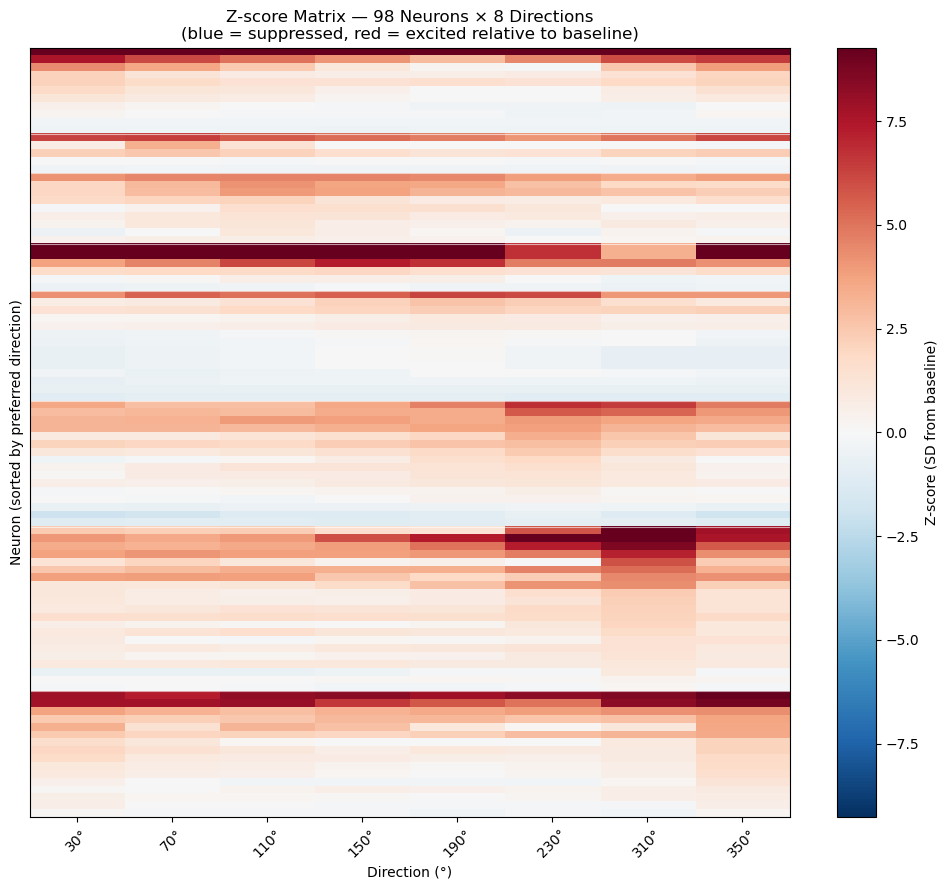

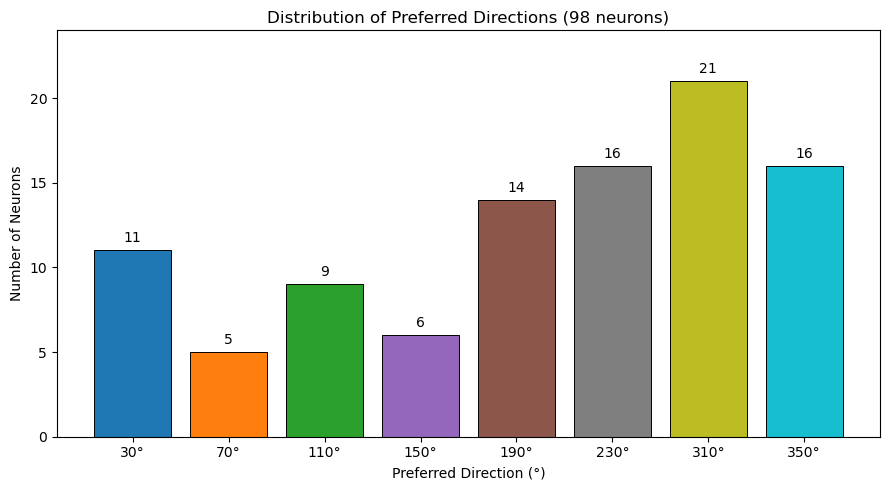

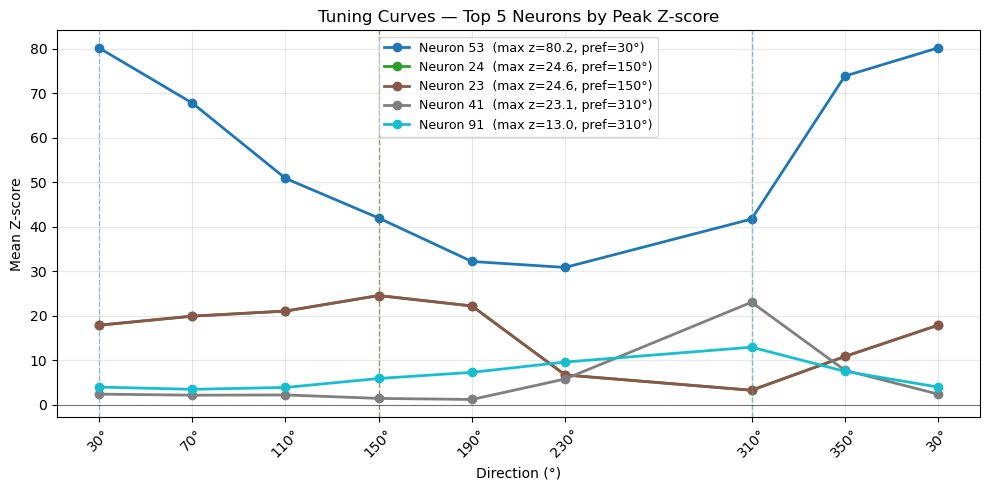

In [72]:
# Section 2, Cell 3: Preferred directions and visualisation

# ── Preferred direction per neuron ─────────────────────────────────────────
pref_dir_idx = np.argmax(z_score, axis=1)   # (num_neurons,) — index into dir_angles
pref_dir     = dir_angles[pref_dir_idx]     # (num_neurons,) — angle in degrees

print("Preferred direction distribution:")
for j, angle in enumerate(dir_angles):
    count = (pref_dir == angle).sum()
    print(f"  {angle:>3}° : {count:>2} neurons  {'|' * count}")

# ── Sort neurons by preferred direction for heatmap ────────────────────────
# Primary sort key: preferred direction index; secondary: highest z-score first
sort_key   = pref_dir_idx * 1000 + (-z_score.max(axis=1))
sort_order = np.argsort(sort_key)
z_sorted   = z_score[sort_order, :]

# ── Figure 1: Z-score heatmap (neurons sorted by preferred direction) ───────
fig1, ax1 = plt.subplots(figsize=(10, 9))

vmax = np.percentile(np.abs(z_score), 97)   # clip extremes so colour scale is not dominated by outliers
im = ax1.imshow(z_sorted, aspect='auto', cmap='RdBu_r',
                vmin=-vmax, vmax=vmax, interpolation='nearest')
ax1.set_xlabel('Direction (°)')
ax1.set_ylabel('Neuron (sorted by preferred direction)')
ax1.set_title('Z-score Matrix — 98 Neurons × 8 Directions\n(blue = suppressed, red = excited relative to baseline)')
ax1.set_xticks(range(num_directions))
ax1.set_xticklabels([f'{a}°' for a in dir_angles], rotation=45)
ax1.set_yticks([])

# Draw boundary lines between preferred-direction groups
sorted_pref = pref_dir[sort_order]
cumulative = 0
for j in range(num_directions - 1):
    count = (sorted_pref == dir_angles[j]).sum()
    cumulative += count
    if count > 0:
        ax1.axhline(cumulative - 0.5, color='white', linewidth=0.8, alpha=0.6)

plt.colorbar(im, ax=ax1, label='Z-score (SD from baseline)')
plt.tight_layout()
plt.show()

# ── Figure 2: Distribution of preferred directions ──────────────────────────
colors_dir = cm.tab10(np.linspace(0, 1, num_directions))
counts = np.array([(pref_dir == angle).sum() for angle in dir_angles])

fig2, ax2 = plt.subplots(figsize=(9, 5))
bars = ax2.bar(range(num_directions), counts, color=colors_dir, edgecolor='black', linewidth=0.7)
ax2.set_xticks(range(num_directions))
ax2.set_xticklabels([f'{a}°' for a in dir_angles])
ax2.set_xlabel('Preferred Direction (°)')
ax2.set_ylabel('Number of Neurons')
ax2.set_title('Distribution of Preferred Directions (98 neurons)')
ax2.set_ylim(0, counts.max() + 3)
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# ── Figure 3: Tuning curves for top-5 neurons ───────────────────────────────
top_n      = 5
top_idx    = np.argsort(z_score.max(axis=1))[::-1][:top_n]
colors_top = cm.tab10(np.linspace(0, 1, top_n))

# Append first angle + 360° to visually close the circular tuning curve
angles_plot = np.append(dir_angles, dir_angles[0] + 360)

fig3, ax3 = plt.subplots(figsize=(10, 5))
for k, n in enumerate(top_idx):
    z_curve = np.append(z_score[n, :], z_score[n, 0])
    ax3.plot(angles_plot, z_curve, color=colors_top[k], linewidth=2, marker='o', markersize=6,
             label=f'Neuron {n}  (max z={z_score[n].max():.1f}, pref={pref_dir[n]}°)')
    ax3.axvline(pref_dir[n], color=colors_top[k], linewidth=1, linestyle='--', alpha=0.4)

ax3.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax3.set_xticks(angles_plot)
ax3.set_xticklabels([f'{a}°' for a in dir_angles] + [f'{dir_angles[0]}°'], rotation=45)
ax3.set_xlabel('Direction (°)')
ax3.set_ylabel('Mean Z-score')
ax3.set_title(f'Tuning Curves — Top {top_n} Neurons by Peak Z-score')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()